# Карта ДТП


Это некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России. Цель проекта — повысить безопасность на дорогах.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах.


## Цель и задачи проекта

В рамках проекта проводится анализ данных о дорожно-транспортных происшествиях.

Основная цель исследования — оценить качество собранных данных, выявив возможные дубликаты и пропущенные значения, а также изучить ключевые закономерности в статистике ДТП.

В ходе работы анализируется:

- как менялось число ДТП по временным промежуткам;

- различается ли число ДТП для групп водителей с разным стажем.

## Описание данных

Данные `Kirovskaya_oblast.csv`, `Moscowskaya_oblast.csv` содержат информацию ДТП:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

*  `properties.tags` — тег происшествия;

*  `properties.light` — освещённость;

*  `properties.point.lat` — широта;

*  `properties.point.long` — долгота;

*  `properties.nearby` — ближайшие объекты;

*  `properties.region` — регион;

*  `properties.scheme` — схема ДТП;

*  `properties.address` — ближайший адрес;

*  `properties.weather` — погода;

*  `properties.category` — категория ДТП;

*  `properties.datetime` — дата и время ДТП;

*  `properties.injured_count` — число пострадавших;

*  `properties.parent_region` — область;

*  `properties.road_conditions` — состояние покрытия;

*  `properties.participants_count` — число участников;

*  `properties.participant_categories` — категории участников.

`Moscowskaya_oblast_participiants.csv`, `Kirovskaya_oblast_participiants.csv` — сведения об участниках ДТП:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после  ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


`Kirovskaya_oblast_vehicles.csv`, `Moscowskaya_oblast_vehicles.csv` — сведения о транспортных средствах:

* `year` — год выпуска;

* `brand` — марка транспортного средства;

* `color` — цвет;

* `model` — модель;

* `category` — категория;

* `id` — идентификатор ДТП.

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Сбор и загрузка данных в Кировской области

In [108]:
#информация о ДТП в Кировской области
ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv')

#информация об участниках ДТП в Кировской области
participants_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv')

#информация о т/с в Кировской области
vehicles_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv')

### Датафрейм ko - информация о ДТП в Кировской области

In [109]:
ko.columns

Index(['geometry.coordinates', 'id', 'properties.tags', 'properties.light',
       'properties.point.lat', 'properties.point.long', 'properties.nearby',
       'properties.region', 'properties.scheme', 'properties.address',
       'properties.weather', 'properties.category', 'properties.datetime',
       'properties.injured_count', 'properties.parent_region',
       'properties.road_conditions', 'properties.participants_count',
       'properties.participant_categories'],
      dtype='object')

In [110]:
#для более удобной работы сокращу названия столбцов
ko.rename(columns={'properties.tags': 'tags', 'properties.light': 'light',
                          'properties.point.lat': 'point.lat', 'properties.point.long': 'point.long',
                          'properties.nearby': 'nearby', 'properties.region': 'region', 'properties.scheme': 'scheme',
                          'properties.address': 'address', 'properties.weather': 'weather', 'properties.category': 'category',
                          'properties.datetime': 'datetime', 'properties.injured_count': 'injured_count', 'properties.parent_region': 'parent_region',
                          'properties.road_conditions': 'road_conditions', 'properties.participants_count': 'participants_count',
                          'properties.participant_categories': 'participant_categories'}, inplace = True)

In [111]:
ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    14517 non-null  object 
 1   id                      14517 non-null  int64  
 2   tags                    14517 non-null  object 
 3   light                   14517 non-null  object 
 4   point.lat               14485 non-null  float64
 5   point.long              14485 non-null  float64
 6   nearby                  14517 non-null  object 
 7   region                  14517 non-null  object 
 8   scheme                  13380 non-null  float64
 9   address                 13843 non-null  object 
 10  weather                 14517 non-null  object 
 11  category                14517 non-null  object 
 12  datetime                14517 non-null  object 
 13  injured_count           14517 non-null  int64  
 14  parent_region           14517 non-null

In [113]:
ko.isna().sum().sort_values(ascending = False)

,0
scheme,1137
address,674
point.long,32
point.lat,32
id,0
geometry.coordinates,0
tags,0
light,0
region,0
nearby,0


In [116]:
#удаляю 32 пропуска
ko = ko.dropna(subset=['point.lat', 'point.long'])

In [117]:
#указываю "схема отсутсвует" и "адрес отсутсвует", чтобы закрыть пропуски
ko['scheme'] = ko['scheme'].fillna('схема отсутствует')
ko['address'] = ko['address'].fillna('адрес отсутствует')

In [118]:
#финально проверяю пропуски
ko.isna().sum()

,0
geometry.coordinates,0
id,0
tags,0
light,0
point.lat,0
point.long,0
nearby,0
region,0
scheme,0
address,0


In [ ]:
#проверяю на явные дубликаты
ko.duplicated().sum()

np.int64(0)

### Датафрейм participants_ko - информация об участниках ДТП в Кировской области

In [ ]:
participants_ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31235 entries, 0 to 31234
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         31235 non-null  object 
 1   gender                       30387 non-null  object 
 2   violations                   31235 non-null  object 
 3   health_status                31135 non-null  object 
 4   years_of_driving_experience  16909 non-null  float64
 5   id                           31235 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


*  В столбце gender - 848 пропусков (2,7%)
*  В столбце health_status - 100 пропусков (0,3%)

Данные пропуски удаляю

In [ ]:
participants_ko = participants_ko.dropna(subset=['gender', 'health_status'])

In [ ]:
participants_ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30385 entries, 0 to 31233
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         30385 non-null  object 
 1   gender                       30385 non-null  object 
 2   violations                   30385 non-null  object 
 3   health_status                30385 non-null  object 
 4   years_of_driving_experience  16726 non-null  float64
 5   id                           30385 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.6+ MB


In [ ]:
participants_ko.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


Есть гипотеза, что NaN в столбце years_of_driving_experience очень много, так как стаж указан только у водителей

In [ ]:
pd.crosstab(
    participants_ko['role'],
    participants_ko['years_of_driving_experience'].isna(),
    margins=True).rename(columns={False: 'Стаж указан', True: 'Стаж не указан'})

years_of_driving_experience,Стаж указан,Стаж не указан,All
role,,,
Велосипедист,0,333,333
Водитель,16726,2290,19016
Пассажир,0,6697,6697
Пешеход,0,4279,4279
"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира",0,60,60
All,16726,13659,30385


In [ ]:
#заменю NaN на "стаж отсутсвует", чтобы закрыть пропуски
participants_ko['years_of_driving_experience'] = participants_ko['years_of_driving_experience'].fillna('стаж отсутствует')

In [ ]:
participants_ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30385 entries, 0 to 31233
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   role                         30385 non-null  object
 1   gender                       30385 non-null  object
 2   violations                   30385 non-null  object
 3   health_status                30385 non-null  object
 4   years_of_driving_experience  30385 non-null  object
 5   id                           30385 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.6+ MB


In [ ]:
#проверяю на явные дубликаты
participants_ko.duplicated().sum()

np.int64(9435)

### Датафрейм vehicles_ko - информация о т/с в Кировской области

In [ ]:
vehicles_ko.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20093 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19299 non-null  float64
 1   brand     19318 non-null  object 
 2   color     19643 non-null  object 
 3   model     19318 non-null  object 
 4   category  20093 non-null  object 
 5   id        20093 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 942.0+ KB


* В столбце year — 794 пропуска (3,95%).

* В столбце brand — 775 пропусков (3,86%).

* В столбце model — 775 пропусков (3,86%).

* В столбце color — 450 пропусков (2,24%).

Доля пропусков во всех столбцах не превышает 5%, поэтому данные пропуски удаляю.

In [ ]:
vehicles_ko = vehicles_ko.dropna(subset=['year', 'brand', 'model', 'color'])

In [ ]:
vehicles_ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19147 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19147 non-null  float64
 1   brand     19147 non-null  object 
 2   color     19147 non-null  object 
 3   model     19147 non-null  object 
 4   category  19147 non-null  object 
 5   id        19147 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


In [ ]:
#проверяю на явные дубликаты
vehicles_ko.duplicated().sum()

np.int64(7)

In [ ]:
vehicles_ko = vehicles_ko.drop_duplicates() #дубликатов очень мало - удаляю

## Сбор и загрузка данных в Московской области

In [ ]:
#информация о ДТП в Московской области
mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv')

#информация об участниках ДТП в Московской области
participants_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv')


#информация о т/с в Московской области
vehicles_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv')

### Датафрейм mo - информация о ДТП в Кировской области

In [ ]:
mo.columns

Index(['geometry.coordinates', 'id', 'properties.tags', 'properties.light',
       'properties.point.lat', 'properties.point.long', 'properties.nearby',
       'properties.region', 'properties.scheme', 'properties.address',
       'properties.weather', 'properties.category', 'properties.datetime',
       'properties.injured_count', 'properties.parent_region',
       'properties.road_conditions', 'properties.participants_count',
       'properties.participant_categories'],
      dtype='object')

In [ ]:
mo.rename(columns={'properties.tags': 'tags', 'properties.light': 'light',
                        'properties.point.lat': 'point.lat', 'properties.point.long': 'point.long',
                        'properties.nearby': 'nearby', 'properties.region': 'region', 'properties.scheme': 'scheme',
                        'properties.address': 'address', 'properties.weather': 'weather', 'properties.category': 'category',
                        'properties.datetime': 'datetime', 'properties.injured_count': 'injured_count', 'properties.parent_region': 'parent_region',
                        'properties.road_conditions': 'road_conditions', 'properties.participants_count': 'participants_count',
                        'properties.participant_categories': 'participant_categories'}, inplace = True)

In [ ]:
mo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45618 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    45618 non-null  object 
 1   id                      45618 non-null  int64  
 2   tags                    45618 non-null  object 
 3   light                   45618 non-null  object 
 4   point.lat               45615 non-null  float64
 5   point.long              45615 non-null  float64
 6   nearby                  45618 non-null  object 
 7   region                  45618 non-null  object 
 8   scheme                  44235 non-null  float64
 9   address                 43862 non-null  object 
 10  weather                 45618 non-null  object 
 11  category                45618 non-null  object 
 12  datetime                45618 non-null  object 
 13  injured_count           45618 non-null  int64  
 14  parent_region           45618 non-null

*    Очень мало пропусков в point.lat и point.long - 3 шт. Это может быть просто ошибка в данных
*    scheme - 1383
*   address - 1756

In [ ]:
#удаляю 32 пропуска
mo = mo.dropna(subset=['point.lat', 'point.long'])

In [ ]:
mo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45615 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    45615 non-null  object 
 1   id                      45615 non-null  int64  
 2   tags                    45615 non-null  object 
 3   light                   45615 non-null  object 
 4   point.lat               45615 non-null  float64
 5   point.long              45615 non-null  float64
 6   nearby                  45615 non-null  object 
 7   region                  45615 non-null  object 
 8   scheme                  44232 non-null  float64
 9   address                 43859 non-null  object 
 10  weather                 45615 non-null  object 
 11  category                45615 non-null  object 
 12  datetime                45615 non-null  object 
 13  injured_count           45615 non-null  int64  
 14  parent_region           45615 non-null  obj

In [ ]:
#указываю "схема отсутсвует" и "адрес отсутсвует", чтобы закрыть пропуски
mo['scheme'] = mo['scheme'].fillna('схема отсутствует')
mo['address'] = mo['address'].fillna('адрес отсутствует')

In [ ]:
mo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45615 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    45615 non-null  object 
 1   id                      45615 non-null  int64  
 2   tags                    45615 non-null  object 
 3   light                   45615 non-null  object 
 4   point.lat               45615 non-null  float64
 5   point.long              45615 non-null  float64
 6   nearby                  45615 non-null  object 
 7   region                  45615 non-null  object 
 8   scheme                  45615 non-null  object 
 9   address                 45615 non-null  object 
 10  weather                 45615 non-null  object 
 11  category                45615 non-null  object 
 12  datetime                45615 non-null  object 
 13  injured_count           45615 non-null  int64  
 14  parent_region           45615 non-null  obj

In [ ]:
#проверяю на явные дубликаты
mo.duplicated().sum()

np.int64(0)

## Динамика ДТП по временным промежуткам в Кировской области

In [120]:
ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14485 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    14485 non-null  object 
 1   id                      14485 non-null  int64  
 2   tags                    14485 non-null  object 
 3   light                   14485 non-null  object 
 4   point.lat               14485 non-null  float64
 5   point.long              14485 non-null  float64
 6   nearby                  14485 non-null  object 
 7   region                  14485 non-null  object 
 8   scheme                  14485 non-null  object 
 9   address                 14485 non-null  object 
 10  weather                 14485 non-null  object 
 11  category                14485 non-null  object 
 12  datetime                14485 non-null  object 
 13  injured_count           14485 non-null  int64  
 14  parent_region           14485 non-null  obj

In [121]:
ko['datetime'] = pd.to_datetime(ko['datetime'])

In [122]:
ko['month'] = ko['datetime'].dt.to_period('M')

ko['week'] = ko['datetime'].dt.day_name()

Проверяю за какое время предоставлены данные

In [123]:
ko['datetime'].min()

Timestamp('2015-01-01 03:45:00')

In [124]:
ko['datetime'].max()

Timestamp('2024-08-31 18:43:00')

Интервал исследования - **с января 2015 года до августа 2024 года:**
*  9 лет и 8 месяцев

### ***Строю график по месяцам и годам за весь период***

In [125]:
df = ko.groupby('month')['id'].size()
df

,id
month,
2015-01,118
2015-02,82
2015-03,74
2015-04,78
2015-05,131
...,...
2024-04,93
2024-05,115
2024-06,187


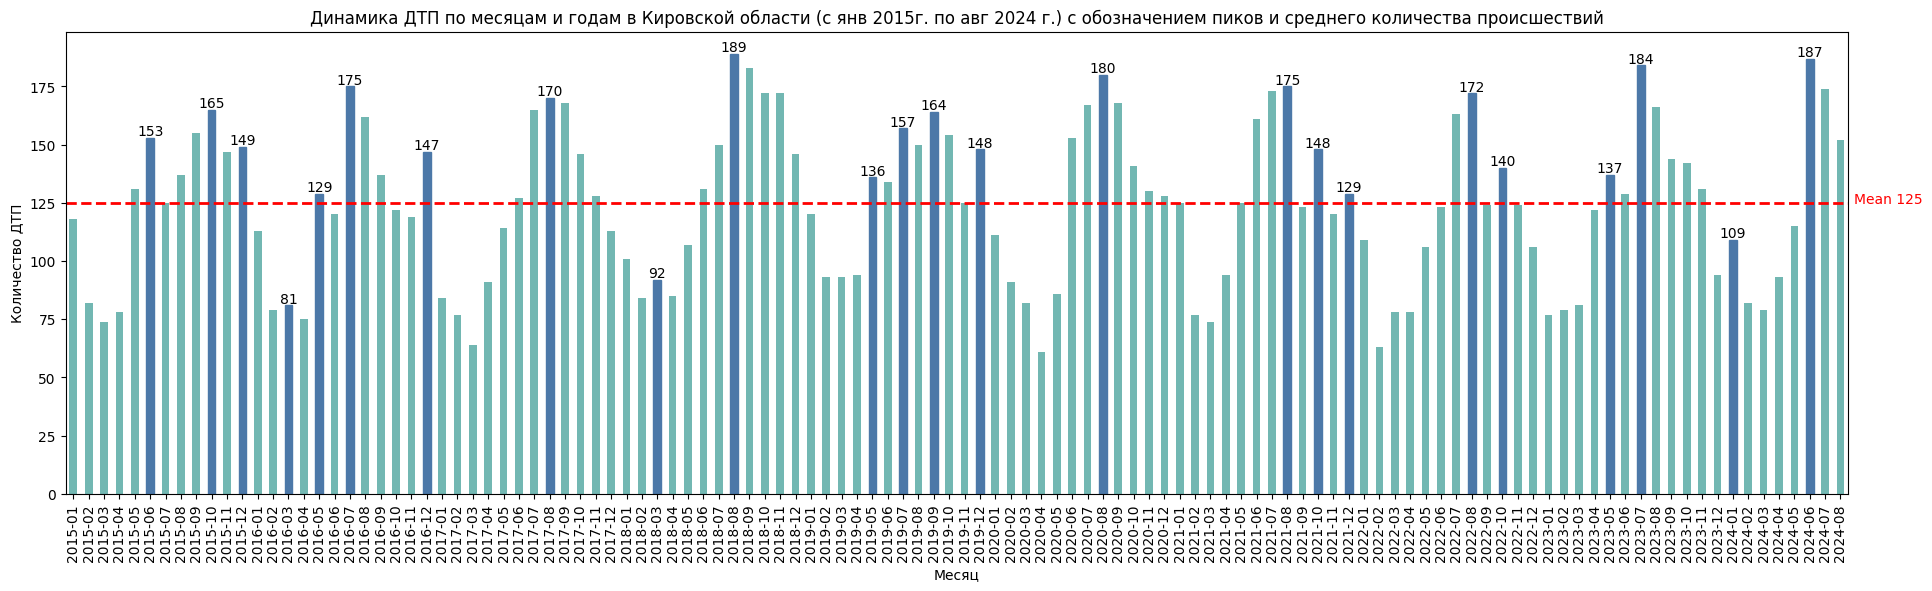

In [126]:
fig, ax = plt.subplots(figsize=(23, 6))

# основной график
bars = df.plot.bar(color='#72B7B2', ax=ax)

values = df.values
peaks = (values > np.roll(values, 1)) & (values > np.roll(values, -1))

# просто перекрашиваем нужные столбцы
for i, bar in enumerate(ax.patches):
    if peaks[i]:
        bar.set_color('#4C78A8')

# подписи пиков
for i, v in enumerate(values):
    if peaks[i]:
        ax.text(i, v + 1, str(v),
                ha='center',
                color='black')

# среднее значение
mean_value1 = df.mean()

ax.axhline(
    y=mean_value1,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value1:.0f}'
)

ax.text(
    len(df) -0.1,
    mean_value1,
    f'Mean {mean_value1:.0f}',
    color='red')

ax.set_xlabel('Месяц')
ax.set_ylabel('Количество ДТП')
ax.set_title('Динамика ДТП по месяцам и годам в Кировской области (с янв 2015г. по авг 2024 г.) с обозначением пиков и среднего количества происшествий')

plt.xticks(rotation=90)
plt.show()

### ***Строю график по дням недели за весь период***

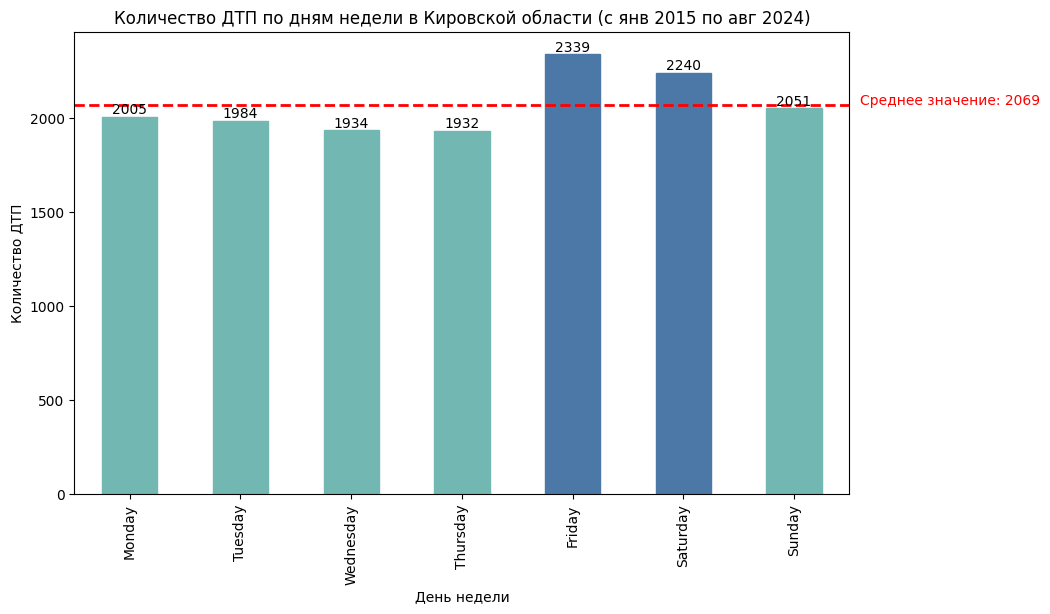

In [127]:
fig, ax = plt.subplots(figsize=(10,6))

df_week.plot.bar(ax=ax)

mean_value_week = df_week.mean()

# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() >= mean_value_week:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

ax.axhline(
    y=mean_value_week,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value_week:.0f}'
)

ax.text(
    len(df_week) - 0.4,
    mean_value_week,
    f'Среднее значение: {mean_value_week:.0f}',
    color='red'
)

ax.set_xlabel('День недели')
ax.set_ylabel('Количество ДТП')
ax.set_title('Количество ДТП по дням недели в Кировской области (с янв 2015 по авг 2024)')

plt.xticks(rotation=90)
plt.show()

### ***Строю график по месяцам за весь период***

In [128]:
ko['month1'] = ko['datetime'].dt.month_name()
ko['year'] = ko['datetime'].dt.year

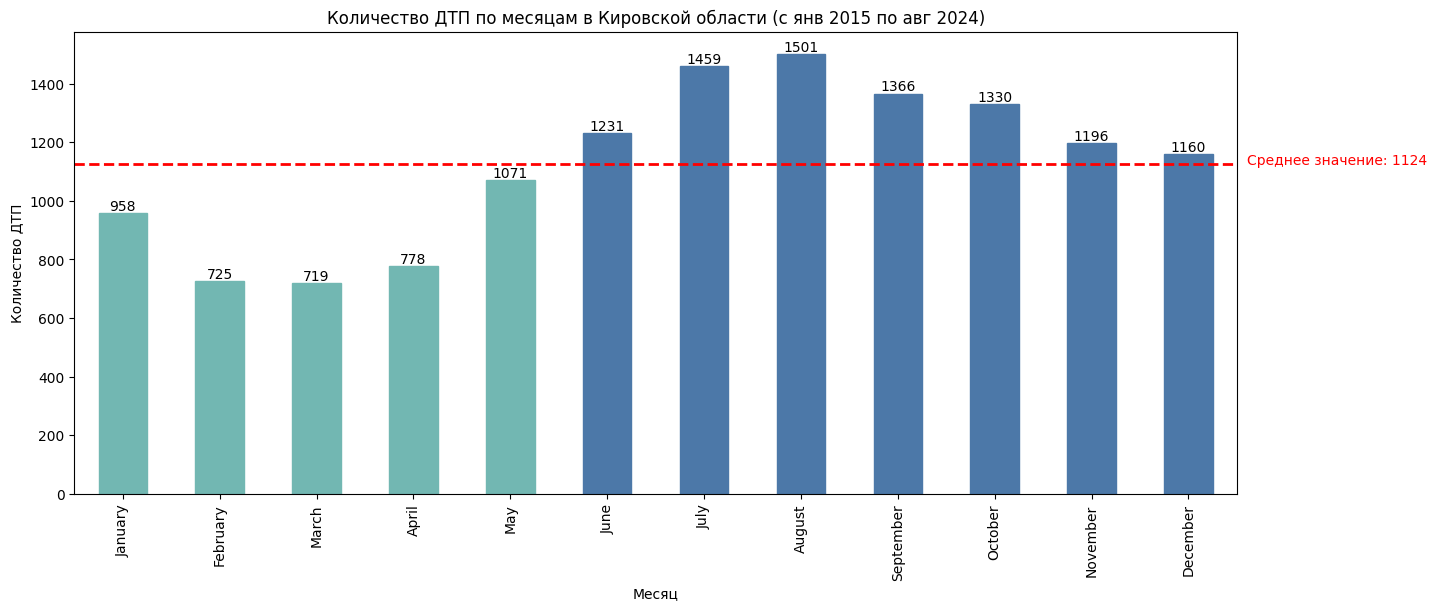

In [130]:
# Месяц с мах кол-вом ДТП

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

ko_m = ko[ko['year'] != 2024].groupby('month1')['id'].size().reindex(month_order)

mean_value2 = ko_m.mean()

# основной график
fig, ax = plt.subplots(figsize=(15,6))

ko_m.plot.bar(color='#72B7B2', ax=ax)


# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() >= mean_value2:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

plt.axhline(
    y=mean_value2,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value2:.0f}')

plt.text(
    len(ko_m) -0.4,
    mean_value2,
    f'Среднее значение: {mean_value2:.0f}',
    color='red')

plt.xlabel('Месяц')
plt.ylabel('Количество ДТП')
plt.title('Количество ДТП по месяцам в Кировской области (с янв 2015 по авг 2024)')
plt.xticks(rotation=90);

### ***Строю график по годам за весь период***

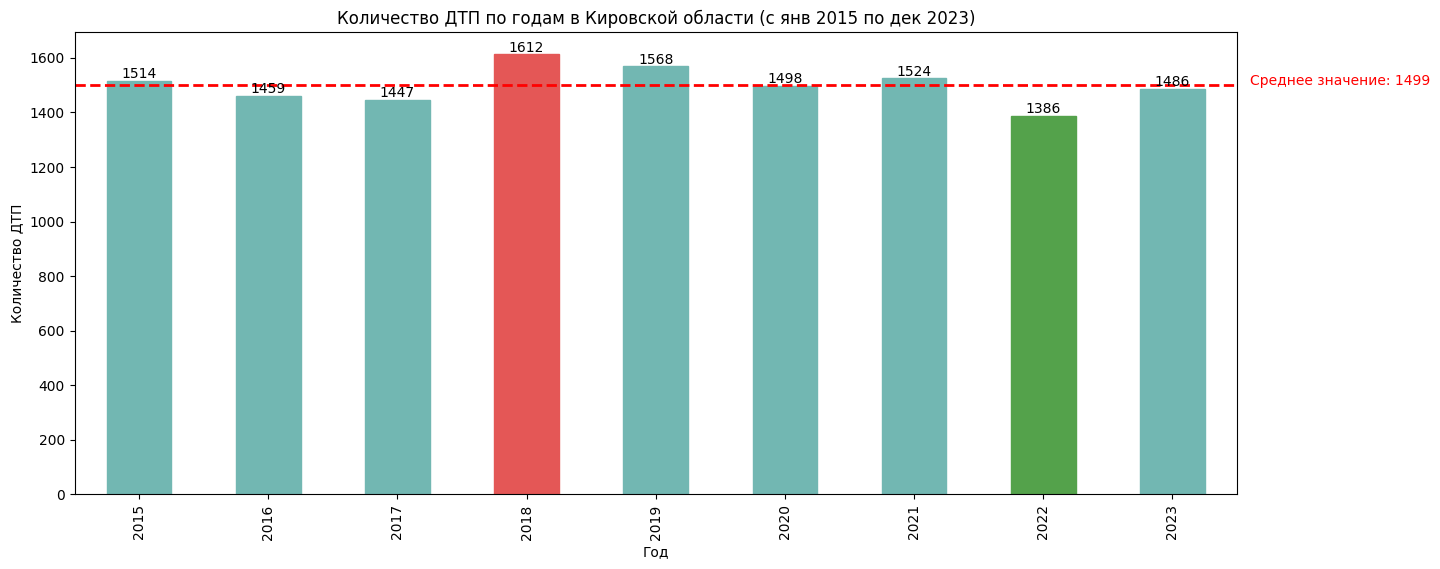

In [103]:
# Год с мах кол-вом ДТП

ko_y = ko[ko['year'] != 2024].groupby('year')['id'].size()

mean_value_year = ko_y.mean()
max_value_year = ko_y.max()
min_value_year = ko_y.min()

# основной график
fig, ax = plt.subplots(figsize=(15,6))
ko_y.plot.bar(color='#72B7B2', ax=ax)

# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() == min_value_year:
        bar.set_color('#54A24B')
    elif bar.get_height() == max_value_year:
        bar.set_color('#E45756')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

plt.axhline(
    y=mean_value_year,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value_year:.0f}')

plt.text(
    len(ko_y) -0.4,
    mean_value_year,
    f'Среднее значение: {mean_value_year:.0f}',
    color='red')

plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.title('Количество ДТП по годам в Кировской области (с янв 2015 по дек 2023)')
plt.xticks(rotation=90);

## Сравнение количества ДТП между группами водителей с разным стажем в Кировской области

In [ ]:
participants_ko

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",стаж отсутствует,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",стаж отсутствует,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639
...,...,...,...,...,...,...
31227,Пешеход,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",стаж отсутствует,1979723
31228,Пешеход,Женский,[],"Раненый, находящийся (находившийся) на стацион...",стаж отсутствует,1986175
31230,Пешеход,Мужской,[],"Раненый, находящийся (находившийся) на стацион...",стаж отсутствует,1982776
31231,Пешеход,Мужской,[],Получил телесные повреждения с показанием к ле...,стаж отсутствует,3011771


In [ ]:
a = participants_ko[(participants_ko['role']=='Водитель') & (participants_ko['years_of_driving_experience'] != 'стаж отсутствует')] \
    .groupby('years_of_driving_experience')['id'].size()

In [ ]:
a

,id
years_of_driving_experience,
1.0,766
2.0,626
3.0,738
4.0,733
5.0,657
...,...
59.0,5
60.0,6
61.0,3


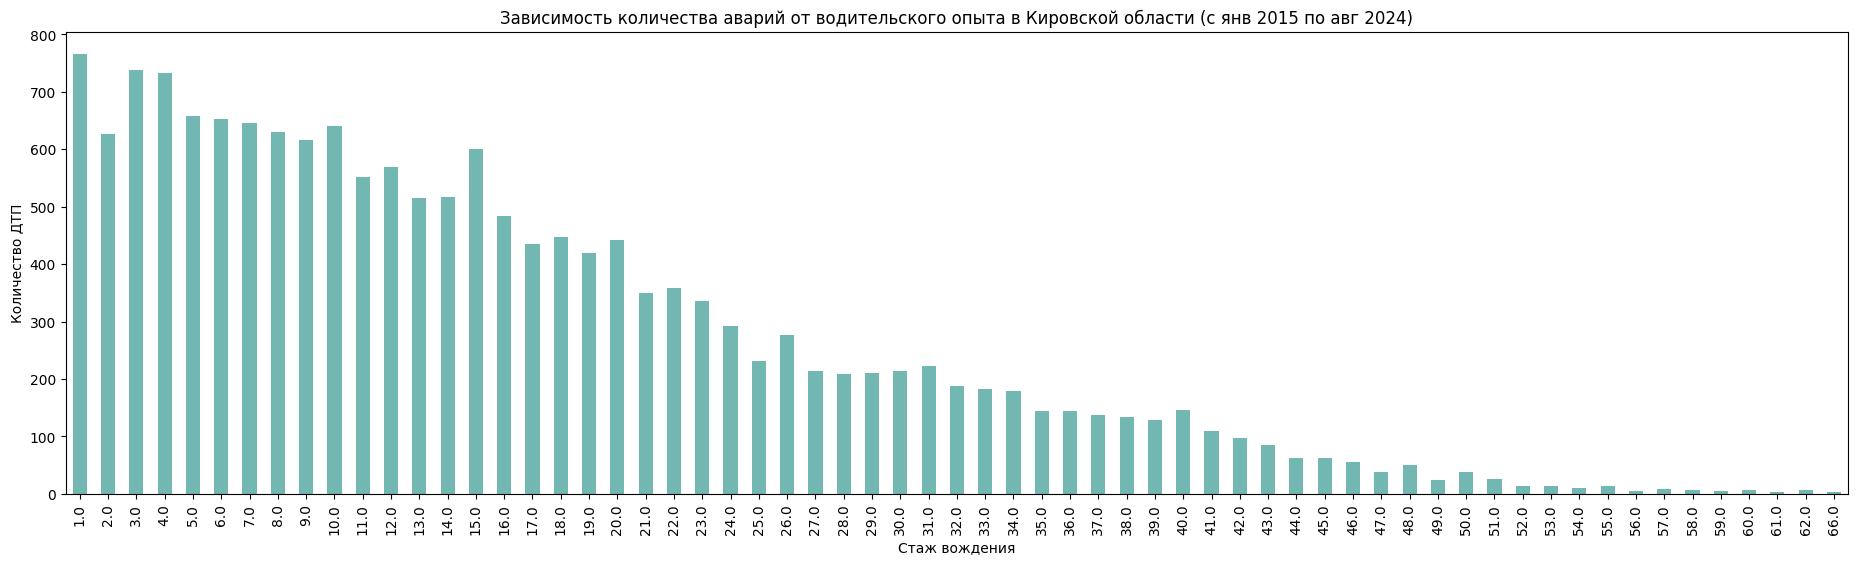

In [ ]:
plt.figure(figsize=(13,6))

a.plot.bar(figsize=(23,6), color='#72B7B2')

plt.xlabel('Стаж вождения')
plt.ylabel('Количество ДТП')
plt.title('Зависимость количества аварий от водительского опыта в Кировской области (с янв 2015 по авг 2024)')
plt.xticks(rotation=90);